In [1]:
import radiate as rd
import polars as pl

rd.random.seed(67123)

### Create a fake dataset 

This dataset is a simple polynomial regression problem with a small it of noise

In [2]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

In [3]:
target_species = 4
species_threshold = 0.2

rolling_species_count = rd.Expr.select("species.count").rolling(25).mean()
err = rd.Expr.select("species.count").error(target_species) * 0.01

### Create the engine

This engine evolves `rd.Graph`s to fit the polynomial regression problem. The vertices of the graph are only allowed to use addition, multiplication, and constants. The engine also tracks the species count and species threshold as metrics, and uses the NEAT distance as a diversity metric.

In [ ]:
collector = rd.MetricCollector()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .diversity(
        rd.Dist.neat(),
        threshold=species_threshold,
        target=target_species,
    )
    .metrics(species_rolling=rolling_species_count, error=err)
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)

2026-07-04T17:10:41.957280Z  INFO Epoch 1    | Score:   2.0038 | Time: 866.54µs
2026-07-04T17:10:41.957988Z  INFO Epoch 2    | Score:   1.6821 | Time: 1.46ms
2026-07-04T17:10:41.958206Z  INFO Epoch 3    | Score:   1.6821 | Time: 1.65ms
2026-07-04T17:10:41.958341Z  INFO Epoch 4    | Score:   1.6821 | Time: 1.77ms
2026-07-04T17:10:41.958773Z  INFO Epoch 5    | Score:   1.6821 | Time: 2.19ms
2026-07-04T17:10:41.958922Z  INFO Epoch 6    | Score:   1.6821 | Time: 2.33ms
2026-07-04T17:10:41.959163Z  INFO Epoch 7    | Score:   1.6820 | Time: 2.50ms
2026-07-04T17:10:41.959424Z  INFO Epoch 8    | Score:   1.6820 | Time: 2.72ms
2026-07-04T17:10:41.959525Z  INFO Epoch 9    | Score:   1.6820 | Time: 2.81ms
2026-07-04T17:10:41.959619Z  INFO Epoch 10   | Score:   1.6820 | Time: 2.89ms
2026-07-04T17:10:41.959759Z  INFO Epoch 11   | Score:   1.6820 | Time: 3.02ms
2026-07-04T17:10:41.959842Z  INFO Epoch 12   | Score:   1.6820 | Time: 3.10ms
2026-07-04T17:10:41.959927Z  INFO Epoch 13   | Score:   1.6820

### Metrics

Using the `rd.MetricCollector` we can aggregate the metrics for the whole engine's run and visualize the metrics we want to track here once the engine has finished. In this case we only want to see our three expressions, but we could also see any `rd.Metric` that the engine tracks - refer to the docs for more details.

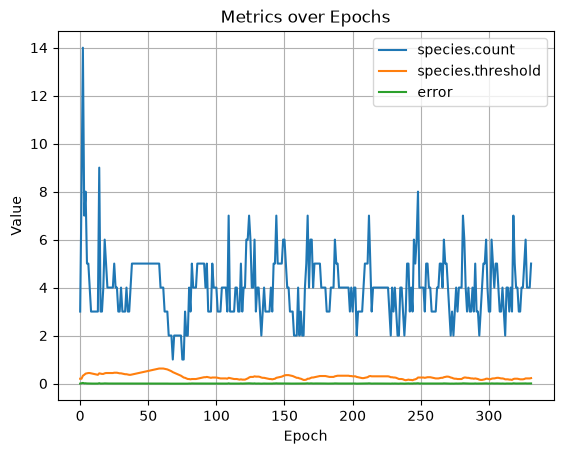

In [5]:
collector.plot(
    "species.count", "species.threshold", "error"
)  # , "species_rolling", "species_count_error", "err")
# collector.plot("err")

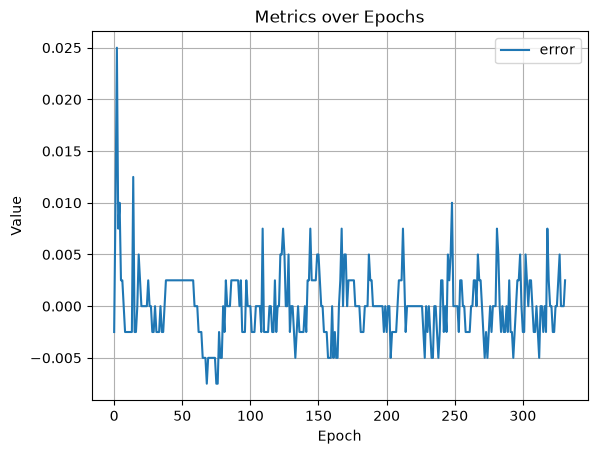

In [6]:
collector.plot("error")

In [7]:
df = collector.to_polars()
df.filter(pl.col("name") == "species.count").tail(20)
# df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""species.count""",2.0,1253.0,4.003195,1.373976,1.88781,5.124277,1.0,14.0,313,null,null,null,null,null,null,312,1,"[""species"", ""statistic""]"
"""species.count""",4.0,1257.0,4.003185,1.371779,1.881779,5.160389,1.0,14.0,314,null,null,null,null,null,null,313,1,"[""species"", ""statistic""]"
"""species.count""",4.0,1261.0,4.003175,1.369593,1.875786,5.196834,1.0,14.0,315,null,null,null,null,null,null,314,1,"[""species"", ""statistic""]"
"""species.count""",3.0,1264.0,4.0,1.368582,1.873016,5.223067,1.0,14.0,316,null,null,null,null,null,null,315,1,"[""species"", ""statistic""]"
"""species.count""",4.0,1268.0,4.0,1.366415,1.867089,5.259935,1.0,14.0,317,null,null,null,null,null,null,316,1,"[""species"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""species.count""",6.0,1316.0,4.012195,1.363517,1.859178,5.196617,1.0,14.0,328,null,null,null,null,null,null,327,1,"[""species"", ""statistic""]"
"""species.count""",4.0,1320.0,4.012158,1.361437,1.85351,5.232661,1.0,14.0,329,null,null,null,null,null,null,328,1,"[""species"", ""statistic""]"
"""species.count""",4.0,1324.0,4.012121,1.359366,1.847877,5.269028,1.0,14.0,330,null,null,null,null,null,null,329,1,"[""species"", ""statistic""]"


In [8]:
df.filter(pl.col("name") == "error").tail(20)

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""error""",-0.005,0.0025,0.000008,0.003435,0.000012,0.0,-0.0075,0.025,313,null,null,null,null,null,null,312,1,"[""statistic"", ""expr""]"
"""error""",0.0,0.0025,0.000008,0.003429,0.000012,0.0,-0.0075,0.025,314,null,null,null,null,null,null,313,1,"[""statistic"", ""expr""]"
"""error""",0.0,0.0025,0.000008,0.003424,0.000012,0.0,-0.0075,0.025,315,null,null,null,null,null,null,314,1,"[""statistic"", ""expr""]"
"""error""",-0.0025,-2.7940e-8,-9.9135e-11,0.003421,0.000012,0.0,-0.0075,0.025,316,null,null,null,null,null,null,315,1,"[""statistic"", ""expr""]"
"""error""",0.0,-2.7940e-8,-9.8822e-11,0.003416,0.000012,0.0,-0.0075,0.025,317,null,null,null,null,null,null,316,1,"[""statistic"", ""expr""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""error""",0.005,0.01,0.00003,0.003409,0.000012,0.0,-0.0075,0.025,328,null,null,null,null,null,null,327,1,"[""statistic"", ""expr""]"
"""error""",0.0,0.01,0.00003,0.003404,0.000012,0.0,-0.0075,0.025,329,null,null,null,null,null,null,328,1,"[""statistic"", ""expr""]"
"""error""",0.0,0.01,0.00003,0.003398,0.000012,0.0,-0.0075,0.025,330,null,null,null,null,null,null,329,1,"[""statistic"", ""expr""]"


In [9]:
print(result.index())
last_version = df.select("generation").max().item()
last_version

332


331